# Color calibration `substrata`

This tutorial walks through color calibration with `substrata` using the "ColorChecker CLASSIC" card. You will load a point cloud, QC the calibration cards, calculate the calibration matrix and offset, and then store it in the project yaml for future use.


In [2]:
%load_ext autoreload
%autoreload 2

from substrata import *

## 1 — Load plot

In [3]:
plot = initializer.ProjectInitializer(yaml='/mnt/int_data/samoa_focal/sam_sa4/sam_sa4_60m/sam_sa4_60m_20251002/sam_sa4_60m_20251002.yaml')

# Setting the PLY to one with 0.5B points to ensure good sampling of the colorchecker card
plot.ply_filepath = '/mnt/int_data/samoa_focal/sam_sa4/sam_sa4_60m/sam_sa4_60m_20251002/sam_sa4_60m_20251002_dec500M.ply'
plot.initialize()

Loading project from YAML file: /mnt/int_data/samoa_focal/sam_sa4/sam_sa4_60m/sam_sa4_60m_20251002/sam_sa4_60m_20251002.yaml
Loading pointcloud from /mnt/int_data/samoa_focal/sam_sa4/sam_sa4_60m/sam_sa4_60m_20251002/sam_sa4_60m_20251002_dec500M.ply
Loading cameras from /mnt/int_data/samoa_focal/sam_sa4/sam_sa4_60m/sam_sa4_60m_20251002/sam_sa4_60m_20251002.meta.json and /mnt/int_data/samoa_focal/sam_sa4/sam_sa4_60m/sam_sa4_60m_20251002/sam_sa4_60m_20251002.cams.xml


No calibration found for sensor 0, skipping...
Missing cx for sensor 1, using default 0.0
Missing cy for sensor 1, using default 0.0
Missing k2 for sensor 1, using default 0.0
Missing k3 for sensor 1, using default 0.0
Missing p1 for sensor 1, using default 0.0
Missing p2 for sensor 1, using default 0.0


Loading markers from /mnt/int_data/samoa_focal/sam_sa4/sam_sa4_60m/sam_sa4_60m_20251002/sam_sa4_60m_20251002_markers.csv
Applying world_transform to loaded objects:
[[-6.89007229e-01 -5.60551498e-02  1.27188372e-02  1.24167737e+01]
 [ 5.65242996e-02 -6.88538024e-01  2.74827717e-02  4.31155990e+00]
 [ 1.04380170e-02  2.84274403e-02  6.90737170e-01 -5.87051791e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Applying colour correction from YAML config


Colour correction: 100%|██████████| 100/100 [00:07<00:00, 12.54it/s]


## 2 — Initialize ColorCalibrations based on marker positions

Initializing `ColorCalibrations` with `calibration_data`, `target_data`,
and `pcd` runs the full calibration pipeline in a single step:

1. **Parses card definitions** — each row in `calibration_data`
   (e.g. `settings.RGL_COLOR_CALIBRATIONS`) provides four marker labels
   (TL, BL, TR, BR) and an optional name. One `ColorCalibration` object
   is created per row.
2. **Resolves 3D coordinates** — matches the corner labels against
   `target_data` (an `Annotations` instance or label→coords dict) to
   assign 3D positions to each card’s four corners.
3. **Samples patch colours** — for every card whose four corners were
   found, bilinear interpolation maps the 24 nominal ColorChecker patch
   positions onto the 3D marker quad. A radius search collects nearby
   points within a thin slab of the card plane, and the median RGB is
   recorded per patch.
4. **Computes cross-card statistics** — the median RGB across all valid
   cards is stored (`median_rgb_255_per_patch`, shape 24×3). A MAD-based
   Z-score flags card/patch combinations that deviate significantly from
   the cross-card median (`outlier_mask`).
5. **Fits an affine colour correction** — solves
   `corrected = M · measured + b` via least-squares over the 24 patches
   (excluding universally flagged outliers). The 3×3 matrix and offset
   are stored in `color_correction` and can later be applied to the
   point cloud or saved to the project YAML.

When `pcd` is omitted only steps 1–2 run; you can call
`sample_point_cloud()` and `compute_color_correction()` separately.


In [6]:
cc = ColorCalibrations(calibration_data=settings.RGL_COLOR_CALIBRATIONS,
                       target_data=plot.markers, pcd=plot.pcd)

## 3 — Visualize and QC the extracted color cards

Projects the point cloud neighbourhood of each card onto the card
plane (using the plane normal as the camera direction). Red dashed
circles mark the sampling area for every colour patch.

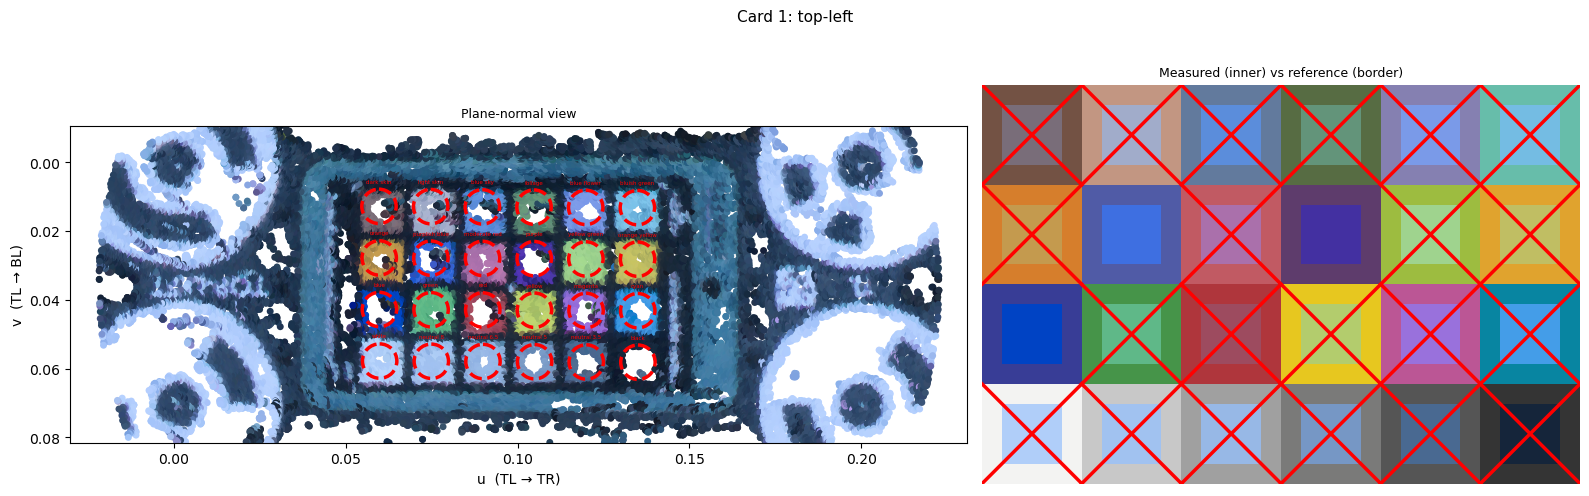

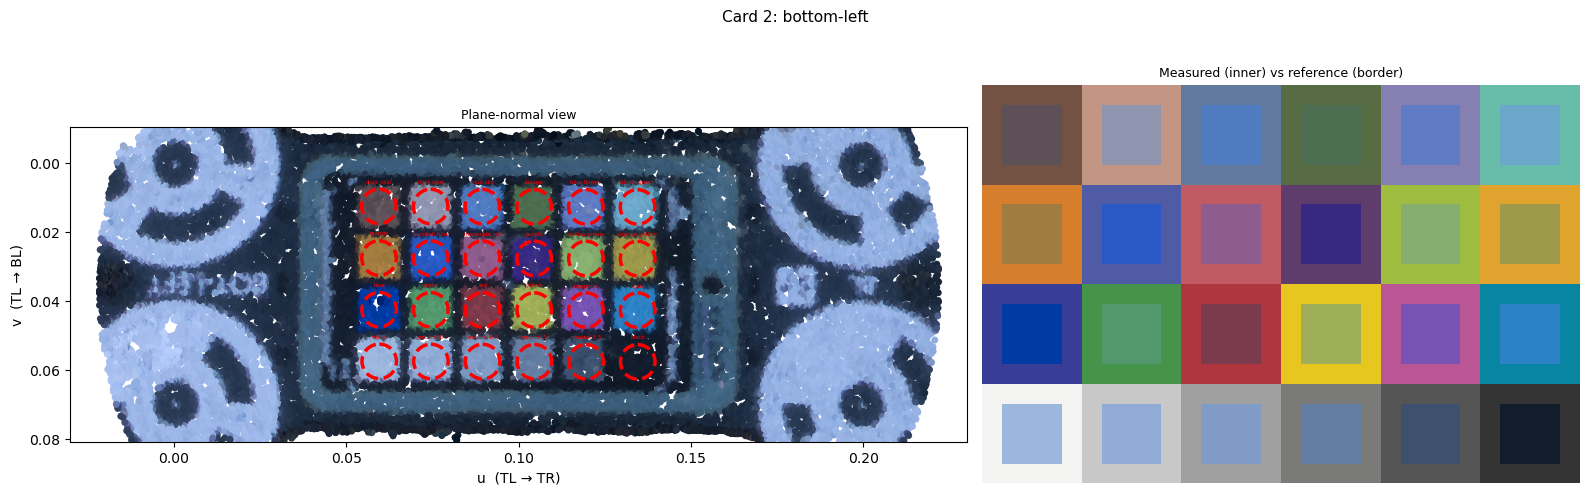

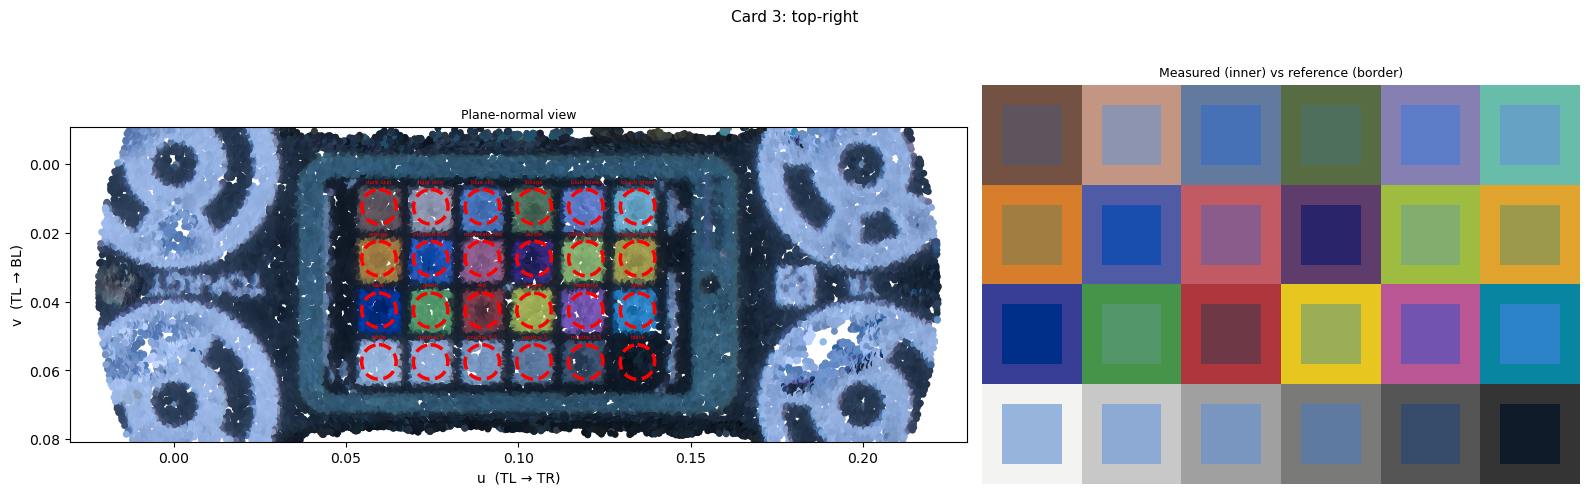

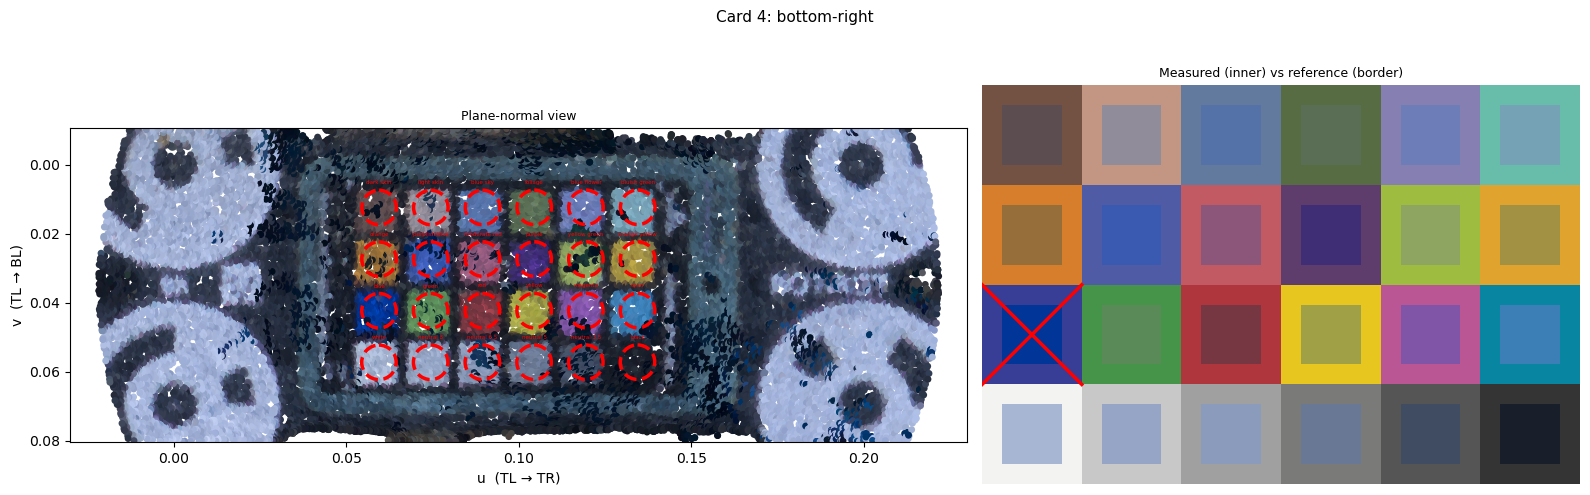

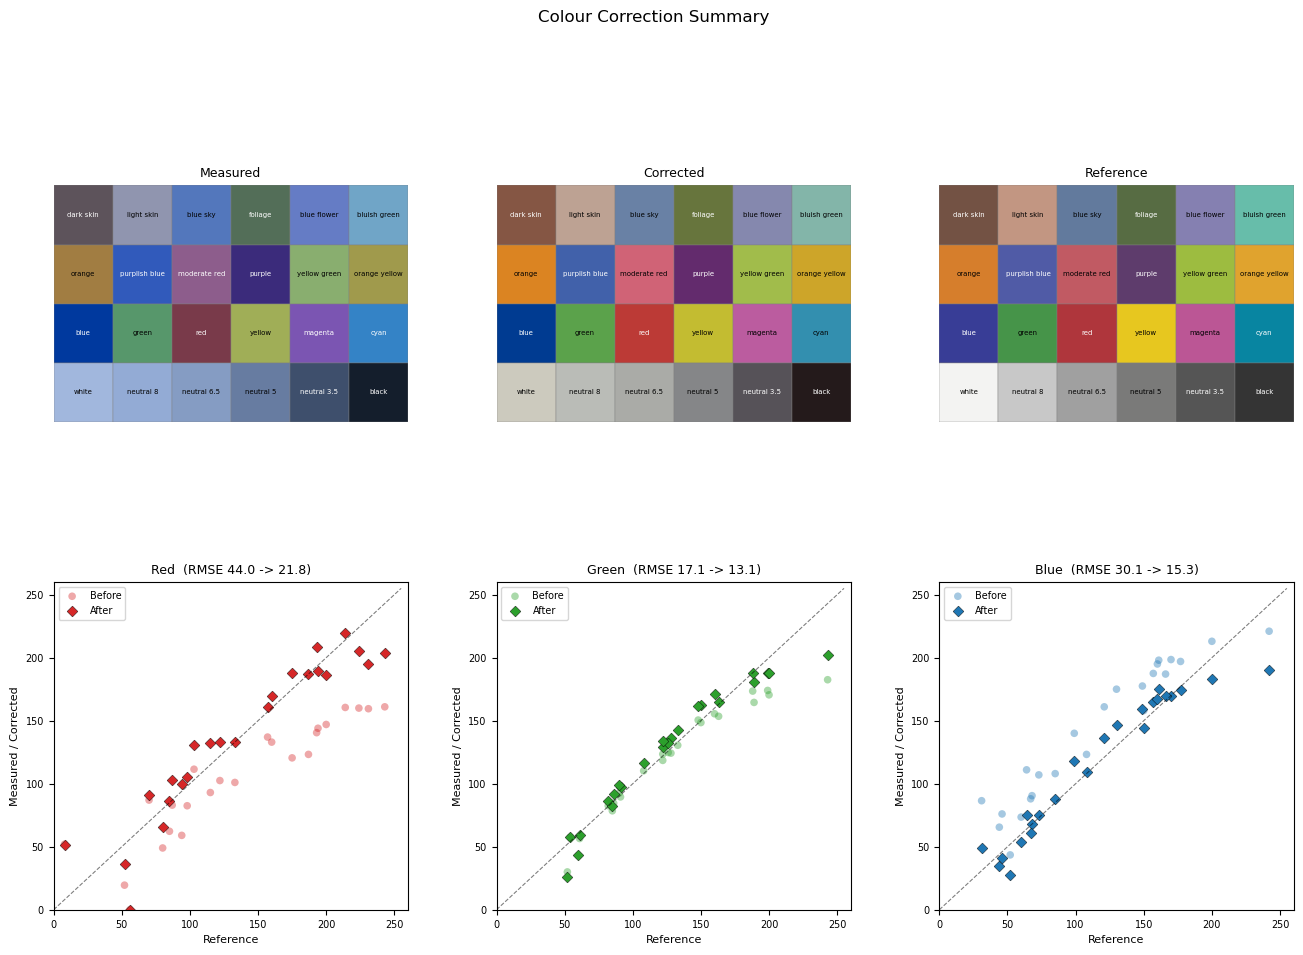

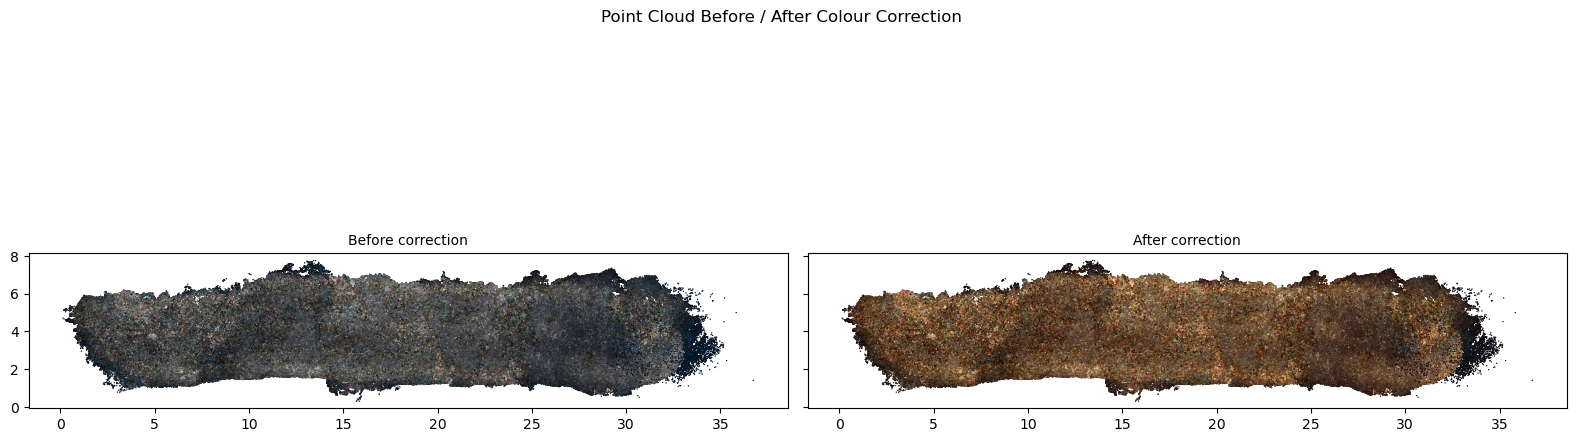

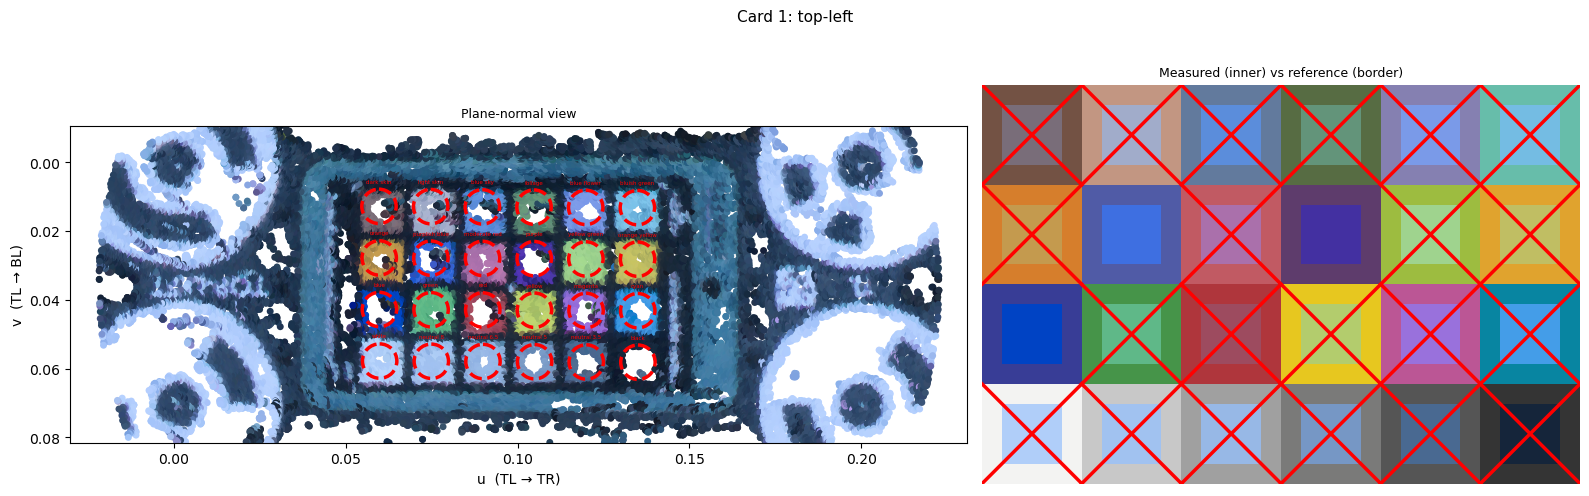

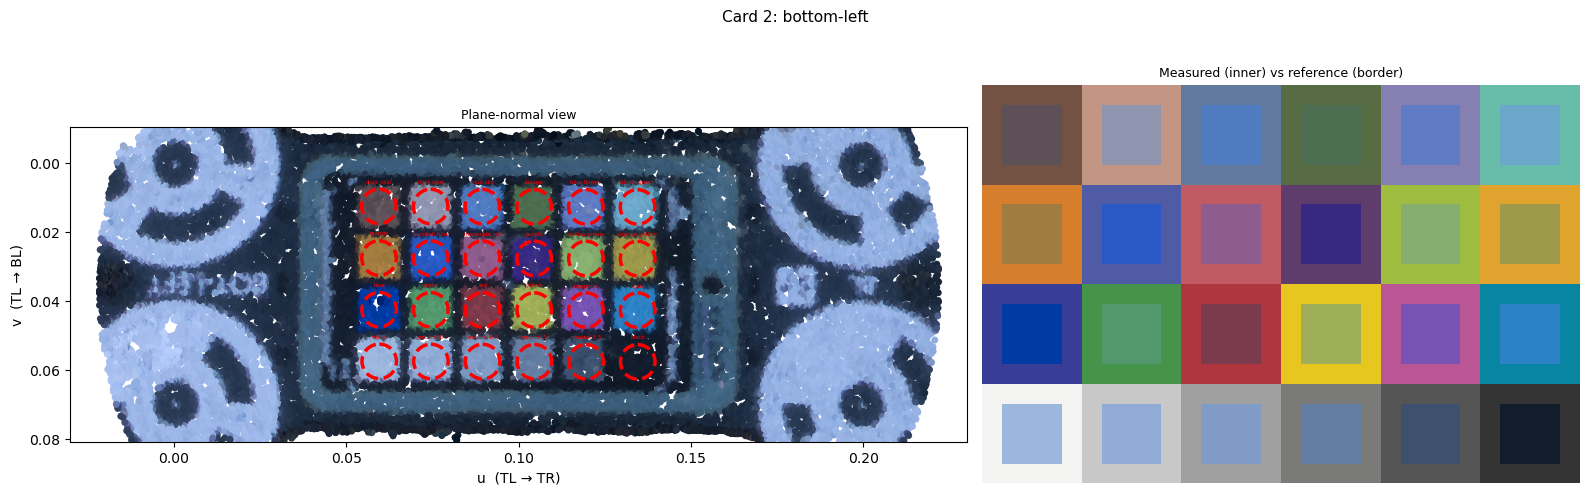

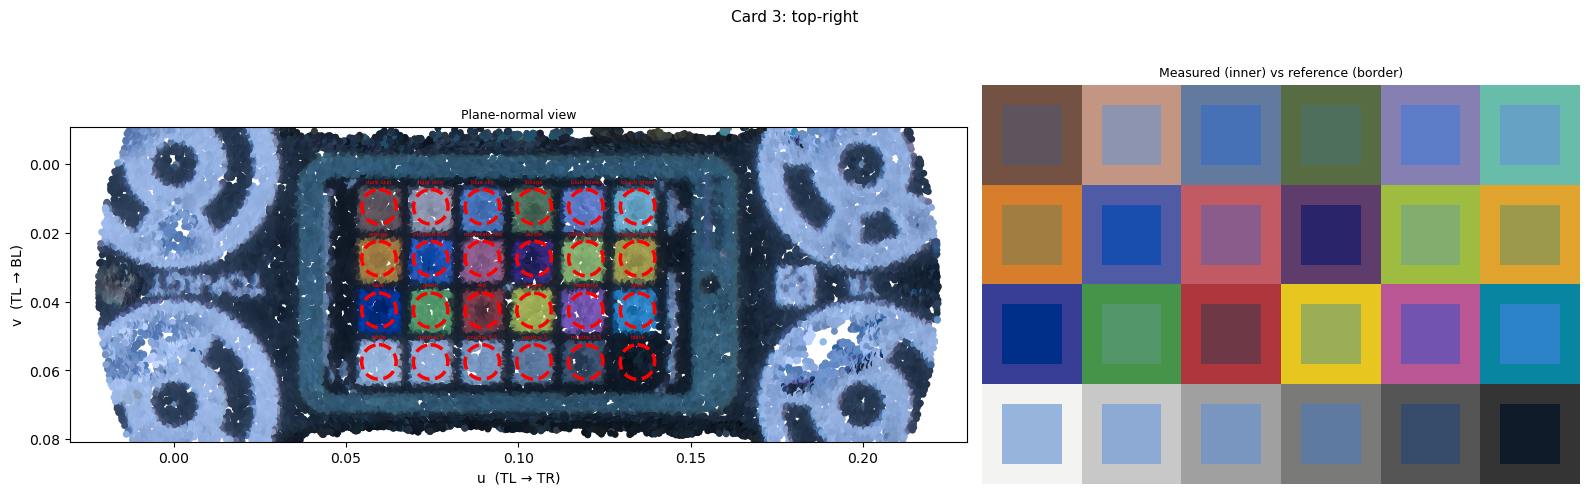

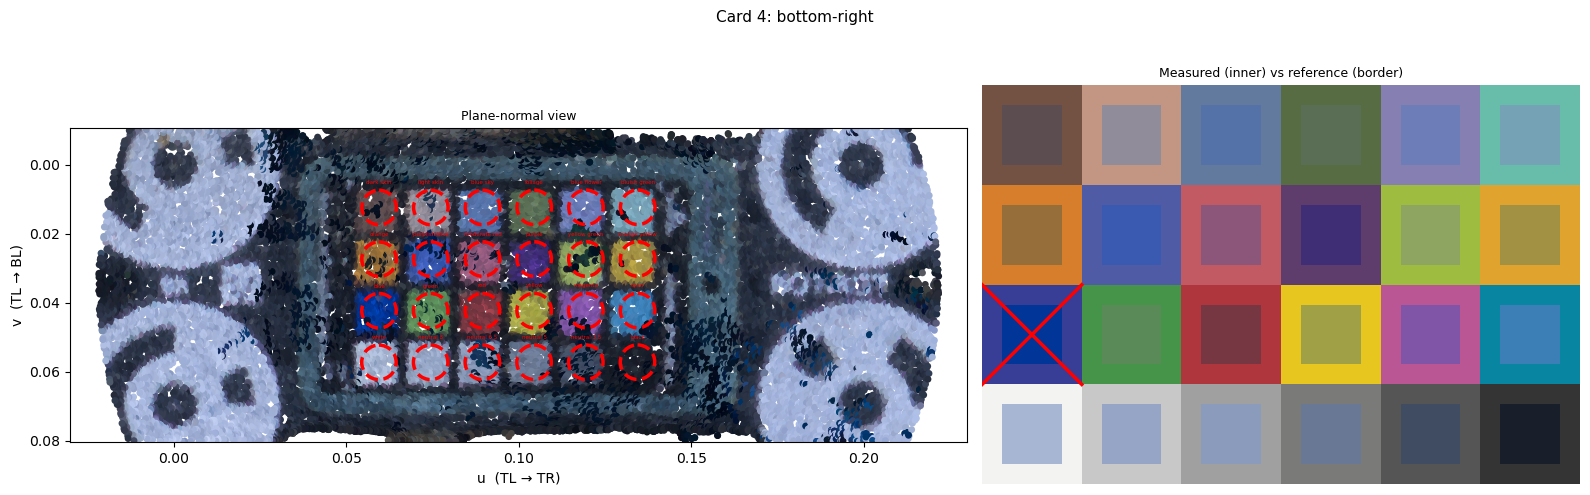

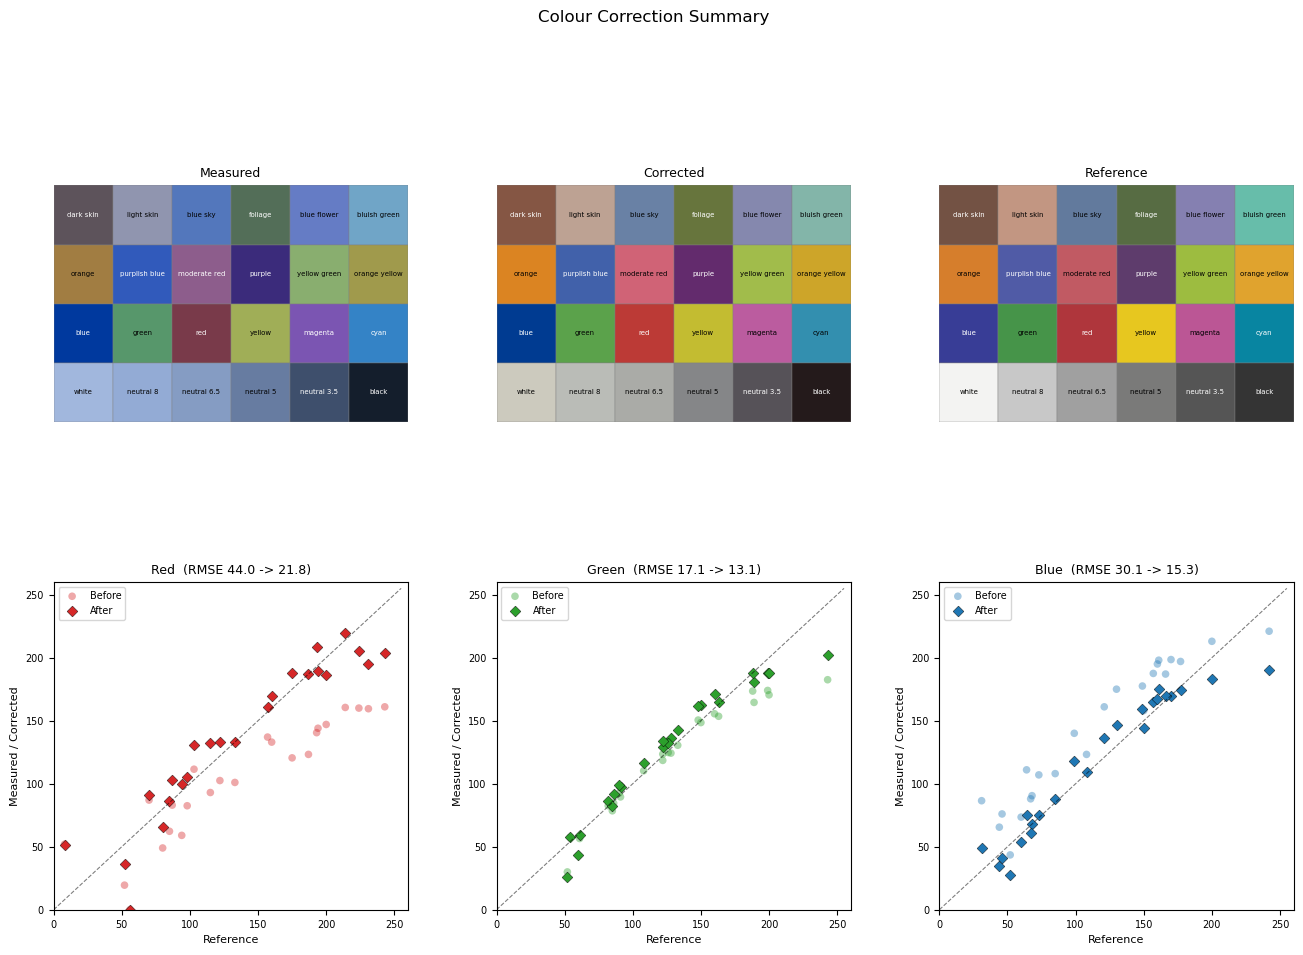

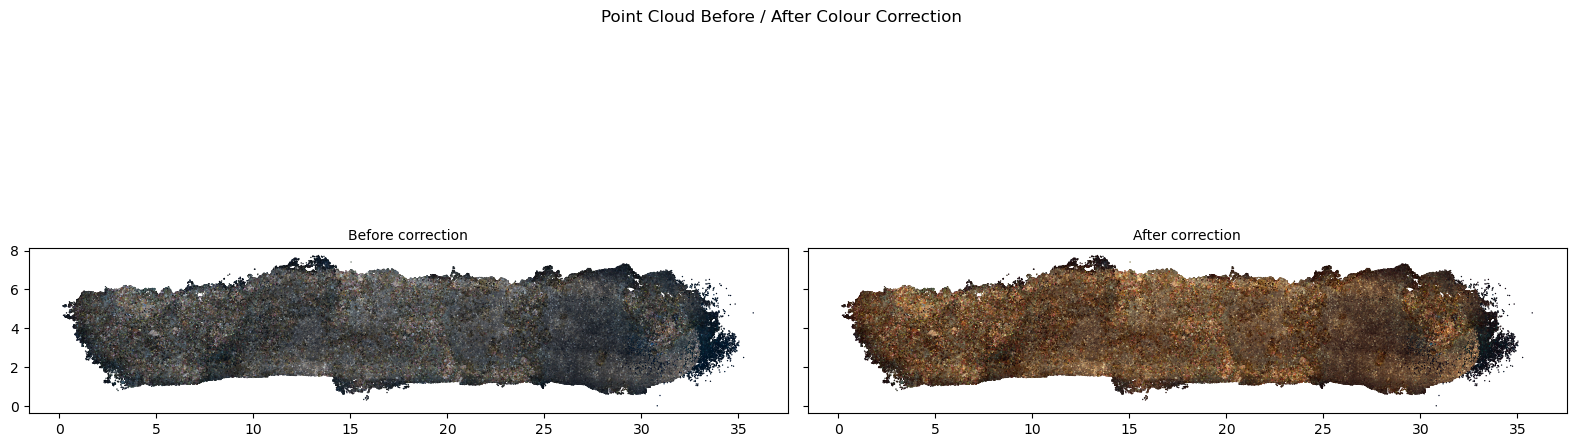

In [7]:
fig = cc.show()
cc.save_pdf()


## 4 - Save color calibration to yaml so that it gets applied on loading

In [ ]:
# Save to yaml file
plot.color_correction = cc.color_correction
plot.save_config_to_yaml()

# Apply calibration to the currently loaded pointcloud (without reloading)
plot.pcd.apply_color_correction(cc.color_correction)

